# Data Exploration

In [17]:
import warnings
warnings.filterwarnings('ignore')

In [18]:
import pandas as pd

df = pd.read_csv("mental_health_social_media_dataset.csv")

df

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Sai Menon,42,1/21/2025,Female,WhatsApp,254,64,0,1,7.7,35,1,5,7,At_Risk
4996,Neha Ansari,33,1/26/2025,Female,TikTok,330,214,1,2,7.4,27,3,7,6,Stressed
4997,Aarav Sharma,13,2/6/2025,Male,TikTok,403,262,2,2,7.0,20,4,9,4,Stressed
4998,Aadhya Patil,21,2/17/2025,Male,TikTok,476,309,2,3,6.6,12,4,9,4,Stressed


In [3]:
print(df.shape)

(5000, 15)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_name                  5000 non-null   object 
 1   age                          5000 non-null   int64  
 2   date                         5000 non-null   object 
 3   gender                       5000 non-null   object 
 4   platform                     5000 non-null   object 
 5   daily_screen_time_min        5000 non-null   int64  
 6   social_media_time_min        5000 non-null   int64  
 7   negative_interactions_count  5000 non-null   int64  
 8   positive_interactions_count  5000 non-null   int64  
 9   sleep_hours                  5000 non-null   float64
 10  physical_activity_min        5000 non-null   int64  
 11  anxiety_level                5000 non-null   int64  
 12  stress_level                 5000 non-null   int64  
 13  mood_level        

In [5]:
print(df.isnull().sum())

person_name                    0
age                            0
date                           0
gender                         0
platform                       0
daily_screen_time_min          0
social_media_time_min          0
negative_interactions_count    0
positive_interactions_count    0
sleep_hours                    0
physical_activity_min          0
anxiety_level                  0
stress_level                   0
mood_level                     0
mental_state                   0
dtype: int64


In [7]:
df.describe()

,age,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,29.947800,373.058200,175.331600,0.864200,1.835400,7.134660,22.693400,2.510400,7.107600,5.625800
std,12.279936,106.003916,71.209329,0.555176,0.943443,0.533184,10.602862,0.794996,1.062378,0.759928
min,13.000000,140.000000,35.000000,0.000000,0.000000,6.400000,8.000000,1.000000,5.000000,4.000000
25%,21.000000,310.000000,118.000000,1.000000,1.000000,6.700000,14.000000,2.000000,6.000000,5.000000
50%,27.000000,388.000000,170.000000,1.000000,2.000000,7.100000,21.000000,3.000000,7.000000,6.000000
75%,35.250000,461.000000,231.000000,1.000000,2.000000,7.450000,29.000000,3.000000,8.000000,6.000000
max,69.000000,520.000000,338.000000,2.000000,4.000000,8.300000,46.000000,4.000000,9.000000,7.000000


# Data Preprocessing

In [8]:
df = df.drop(["person_name","date"], axis=1)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["platform"] = le.fit_transform(df["platform"])
df["mental_state"] = le.fit_transform(df["mental_state"])

# EDA

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

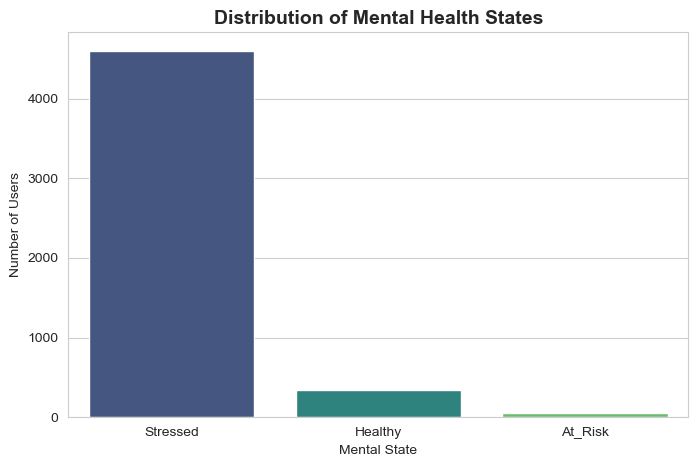

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(x="mental_state", data=df, palette="viridis")

plt.title("Distribution of Mental Health States", fontsize=14, fontweight="bold")
plt.xlabel("Mental State")
plt.ylabel("Number of Users")

plt.show()

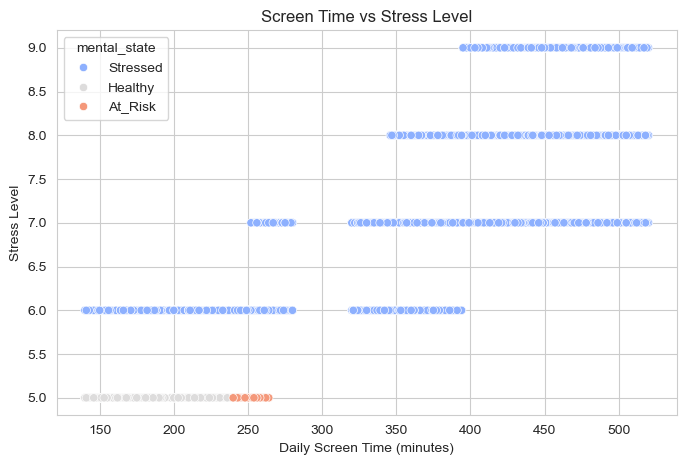

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="daily_screen_time_min",
    y="stress_level",
    hue="mental_state",
    palette="coolwarm",
    data=df
)

plt.title("Screen Time vs Stress Level")
plt.xlabel("Daily Screen Time (minutes)")
plt.ylabel("Stress Level")

plt.show()

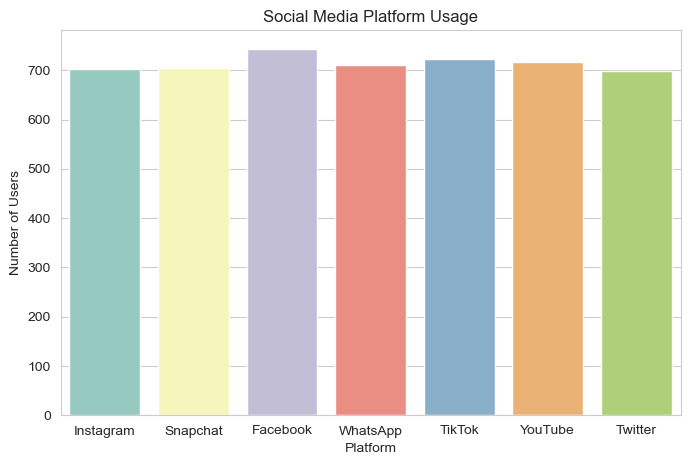

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x="platform", data=df, palette="Set3")

plt.title("Social Media Platform Usage")
plt.xlabel("Platform")
plt.ylabel("Number of Users")

plt.show()

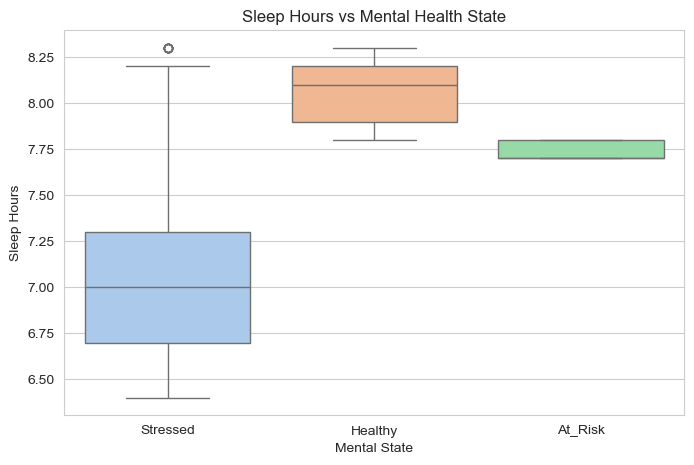

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="mental_state",
    y="sleep_hours",
    palette="pastel",
    data=df
)

plt.title("Sleep Hours vs Mental Health State")
plt.xlabel("Mental State")
plt.ylabel("Sleep Hours")

plt.show()

# Feature Selection

In [14]:
X = df.drop("mental_state", axis=1)
y = df["mental_state"]

# Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Model Training

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [22]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train,y_train)

SVC()

# Model Evaluation

In [24]:
from sklearn.metrics import f1_score,classification_report, accuracy_score, confusion_matrix

pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))

Accuracy: 0.993

Confusion Matrix:
 [[ 10   1   1]
 [  0  71   2]
 [  0   3 912]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.95      0.97      0.96        73
           2       1.00      1.00      1.00       915

    accuracy                           0.99      1000
   macro avg       0.98      0.93      0.96      1000
weighted avg       0.99      0.99      0.99      1000



In [25]:
pred1 = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred1))
print("\nClassification Report:\n", classification_report(y_test, pred1))

Accuracy: 1.0

Confusion Matrix:
 [[ 12   0   0]
 [  0  73   0]
 [  0   0 915]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        73
           2       1.00      1.00      1.00       915

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [26]:
pred2 = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred2))
print("\nClassification Report:\n", classification_report(y_test, pred2))

Accuracy: 1.0

Confusion Matrix:
 [[ 12   0   0]
 [  0  73   0]
 [  0   0 915]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        73
           2       1.00      1.00      1.00       915

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



# Save Model (Pickle)

In [27]:
import pickle

pickle.dump(rf, open("mental_health_model.pkl","wb"))